<a href="https://colab.research.google.com/github/MKumaraShiva/MKumaraShiva/blob/main/Amlt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision scikit-learn pandas matplotlib seaborn

In [2]:

import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.model_selection import train_test_split

In [4]:
num_samples = 1000

image_data = np.random.rand(num_samples, 512)
tabular_data = np.random.rand(num_samples, 3)
time_series = np.random.rand(num_samples, 30)

labels = np.random.randint(0, 5, num_samples)

In [5]:
X_img_train, X_img_test, X_tab_train, X_tab_test, X_time_train, X_time_test, y_train, y_test = train_test_split(
    image_data, tabular_data, time_series, labels, test_size=0.2, random_state=42
)

In [6]:
X_img_train = torch.tensor(X_img_train, dtype=torch.float32)
X_tab_train = torch.tensor(X_tab_train, dtype=torch.float32)
X_time_train = torch.tensor(X_time_train, dtype=torch.float32)

X_img_test = torch.tensor(X_img_test, dtype=torch.float32)
X_tab_test = torch.tensor(X_tab_test, dtype=torch.float32)
X_time_test = torch.tensor(X_time_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [7]:
class TrimodalModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.img_fc = nn.Linear(512, 128)

        self.tab_fc = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.gru = nn.GRU(input_size=1, hidden_size=32, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(128 + 16 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 5)
        )

    def forward(self, img, tab, time):
        img_out = torch.relu(self.img_fc(img))

        tab_out = self.tab_fc(tab)

        time = time.unsqueeze(-1)
        _, h = self.gru(time)
        time_out = h.squeeze(0)

        combined = torch.cat([img_out, tab_out, time_out], dim=1)
        return self.fc(combined)

model = TrimodalModel()

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()

    outputs = model(X_img_train, X_tab_train, X_time_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.6085
Epoch 2, Loss: 1.6022
Epoch 3, Loss: 1.5986
Epoch 4, Loss: 1.5960
Epoch 5, Loss: 1.5924
Epoch 6, Loss: 1.5889
Epoch 7, Loss: 1.5844
Epoch 8, Loss: 1.5796
Epoch 9, Loss: 1.5744
Epoch 10, Loss: 1.5686


In [9]:
model.eval()

with torch.no_grad():
    outputs = model(X_img_test, X_tab_test, X_time_test)
    _, preds = torch.max(outputs, 1)

y_true = y_test.numpy()
y_pred = preds.numpy()

In [10]:
accuracy = np.mean(y_true == y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Cohen Kappa:", kappa)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.16
Cohen Kappa: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       0.00      0.00      0.00        31
           2       0.16      1.00      0.28        32
           3       0.00      0.00      0.00        61
           4       0.00      0.00      0.00        37

    accuracy                           0.16       200
   macro avg       0.03      0.20      0.06       200
weighted avg       0.03      0.16      0.04       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


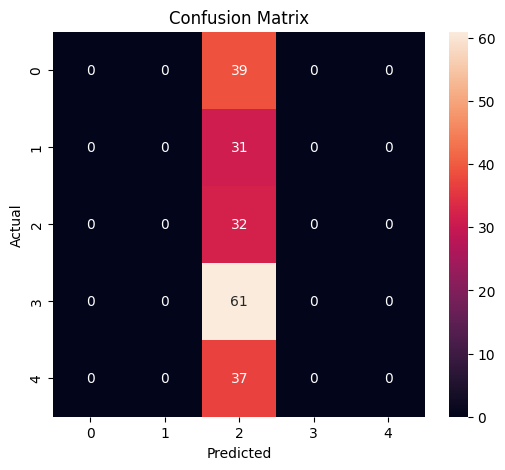

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()